In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno
from scipy import stats
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Display every column
pd.options.display.max_rows = None
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('data_export_imputed05.csv')

In [3]:
df.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,Q9I,Q9E,Q10A,Q10I,Q10E,Q11A,Q11I,Q11E,Q12A,Q12I,Q12E,Q13A,Q13I,Q13E,Q14A,Q14I,Q14E,Q15A,Q15I,Q15E,Q16A,Q16I,Q16E,Q17A,Q17I,Q17E,Q18A,Q18I,Q18E,Q19A,Q19I,Q19E,Q20A,Q20I,Q20E,Q21A,Q21I,Q21E,Q22A,Q22I,Q22E,Q23A,Q23I,Q23E,Q24A,Q24I,Q24E,Q25A,Q25I,Q25E,Q26A,Q26I,Q26E,Q27A,Q27I,Q27E,Q28A,Q28I,Q28E,Q29A,Q29I,Q29E,Q30A,Q30I,Q30E,Q31A,Q31I,Q31E,Q32A,Q32I,Q32E,Q33A,Q33I,Q33E,Q34A,Q34I,Q34E,Q35A,Q35I,Q35E,Q36A,Q36I,Q36E,Q37A,Q37I,Q37E,Q38A,Q38I,Q38E,Q39A,Q39I,Q39E,Q40A,Q40I,Q40E,Q41A,Q41I,Q41E,Q42A,Q42I,Q42E,country,source,introelapse,testelapse,surveyelapse,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,VCL1,VCL2,VCL3,VCL4,VCL5,VCL6,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize
0,3,28,3890.0,3,25,2122.0,1,16,1944.0,3,8,2044.0,3,34,2153.0,3,33,2416.0,3,10,2818.0,3,13,2259.0,1,21,5541.0,0,38,4441.0,3,31,2451.0,3,24,3325.0,3,14,1416.0,3,37,5021.0,3,27,2342.0,3,39,2480.0,2,6,2476.0,3,35,1627.0,2,17,9050.0,2,30,7001.0,0,11,4719.0,3,20,2984.0,3,36,1313.0,3,42,2444.0,3,1,9880.0,3,2,4695.0,3,5,1677.0,2,4,6723.0,3,3,5953.0,1,26,8062.0,3,12,5560.0,3,7,3032.0,1,29,3316.0,2,40,3563.0,3,23,5594.0,3,41,1477.0,0,18,3885.0,1,9,5265.0,3,19,1892.0,2,22,4228.0,3,32,1574.0,3,15,2969.0,IN,2,19.0,167.0,166.0,1,5,7,7,7,7,7,5,1,1,1,0,0,1,1,0,1,0,0,1,0,0,0,1,1,1,2.0,3.0,2.0,2.0,16,1,1,1.0,12.0,1.0,1,2.0,1.0,2
1,3,2,8118.0,0,36,2890.0,1,35,4777.0,2,28,3090.0,3,10,5078.0,3,40,2790.0,2,18,3408.0,3,1,8342.0,2,37,916.0,1,32,1537.0,1,21,3926.0,1,25,3691.0,3,26,2004.0,3,4,8888.0,2,27,4109.0,2,19,4058.0,3,12,3692.0,1,6,3373.0,0,23,6015.0,0,16,3023.0,1,22,2670.0,2,3,5727.0,0,39,3641.0,1,33,2670.0,1,7,7649.0,2,11,2537.0,2,5,2907.0,3,9,1685.0,2,41,4726.0,2,17,6063.0,1,20,3307.0,2,14,4995.0,2,38,2505.0,1,34,2540.0,1,31,4359.0,2,15,3925.0,3,13,4609.0,1,30,3755.0,1,42,2323.0,0,24,5713.0,1,8,1334.0,1,29,5562.0,US,2,1.0,193.0,186.0,6,5,4,7,5,4,7,7,1,5,1,1,0,1,1,0,0,0,0,1,0,0,0,1,1,1,2.0,3.0,2.0,1.0,16,2,1,2.0,7.0,1.0,7,2.0,1.0,4
2,2,7,5784.0,0,33,4373.0,3,41,3242.0,0,13,6470.0,3,11,3927.0,2,9,3704.0,0,17,4550.0,2,5,3021.0,1,32,5864.0,3,21,3722.0,1,10,3424.0,0,36,3236.0,3,23,2489.0,0,34,7290.0,3,12,6587.0,3,22,3627.0,3,38,2905.0,1,18,2998.0,1,8,10233.0,0,16,4258.0,3,28,2888.0,2,4,3180.0,1,3,11732.0,3,2,8834.0,1,29,7358.0,0,30,4928.0,1,15,3036.0,0,19,4127.0,1,37,3934.0,1,26,10782.0,3,1,8273.0,2,39,3501.0,0,27,3824.0,3,25,2141.0,2,6,17461.0,3,24,1557.0,3,40,4446.0,3,42,1883.0,1,35,5790.0,1,14,4432.0,0,20,2203.0,3,31,5768.0,PL,2,5.0,271.0,122.0,2,5,2,2,5,6,5,5,3,2,1,0,0,1,1,0,0,0,0,0,1,0,0,1,1,1,2.0,3.0,2.0,2.0,17,2,1,1.0,4.0,3.0,6,1.0,1.0,3
3,1,23,5081.0,2,11,6837.0,1,37,5521.0,0,27,4556.0,2,28,3269.0,2,26,3231.0,3,2,7138.0,1,19,3079.0,2,31,9650.0,2,17,4179.0,1,5,5928.0,0,21,2838.0,0,20,2560.0,3,29,5139.0,1,22,3597.0,1,35,3336.0,2,10,4506.0,0,14,2695.0,0,25,8128.0,1,15,3125.0,0,6,4061.0,0,40,4272.0,0,12,4029.0,0,9,5630.0,0,18,30631.0,1,24,9870.0,3,4,2411.0,0,16,9478.0,2,1,7618.0,2,32,12639.0,2,34,5378.0,0,41,8923.0,1,38,2977.0,3,3,5620.0,0,7,16760.0,0,8,6427.0,1,39,3760.0,0,13,4112.0,2,42,2769.0,3,33,4432.0,3,30,3643.0,1,36,3698.0,US,2,3.0,261.0,336.0,1,1,7,4,6,4,6,1,6,1,1,0,0,1,1,0,0,0,0,1,0,0,0,1,1,1,1.0,3.0,2.0,1.0,13,2,1,2.0,4.0,5.0,7,2.0,1.0,5
4,1,36,3215.0,1,13,7731.0,2,5,4156.0,3,10,2802.0,3,2,5628.0,1,9,6522.0,3,34,2374.0,3,11,3054.0,3,7,2975.0,2,14,3524.0,1,33,3033.0,3,23,2132.0,3,17,1314.0,3,16,3181.0,3,26,2249.0,2,19,2623.0,3,35,3093.0,3,38,7098.0,3,37,1938.0,3,15,3502.0,2,32,4776.0,2,18,4463.0,3,4,2436.0,1,40,4047.0,3,31,3787.0,3,42,2102.0,1,1,12351.0,3,3,2410.0,1,22,5056.0,3,39,3343.0,2,27,3012.0,3,20,3520.0,3,8,1868.0,3,25,2536.0,2,24,3725.0,3,30,2130.0,2,29,3952.0,2,21,10694.0,2,41,3231.0,3,12,3604.0,3,28,1950.0,2,6,6265.0,MY,2,7.0,164.0,157.0,2,5,3,6,5,5,5,6,3,3,1,1,0,1,1,0,0,1,0,1,0,0,1,1,1,1,3.0,2.0,2.0,2.0,19,2,2,3.0

## Checking Dataset Quality

In [4]:
missing_data = df.isnull().mean() * 100
print(missing_data)

Q1A                      0.0
Q1I                      0.0
Q1E                      0.0
Q2A                      0.0
Q2I                      0.0
Q2E                      0.0
Q3A                      0.0
Q3I                      0.0
Q3E                      0.0
Q4A                      0.0
Q4I                      0.0
Q4E                      0.0
Q5A                      0.0
Q5I                      0.0
Q5E                      0.0
Q6A                      0.0
Q6I                      0.0
Q6E                      0.0
Q7A                      0.0
Q7I                      0.0
Q7E                      0.0
Q8A                      0.0
Q8I                      0.0
Q8E                      0.0
Q9A                      0.0
Q9I                      0.0
Q9E                      0.0
Q10A                     0.0
Q10I                     0.0
Q10E                     0.0
Q11A                     0.0
Q11I                     0.0
Q11E                     0.0
Q12A                     0.0
Q12I          

In [5]:
missing_data_total = df.isnull().stack().mean() * 100
print(f"Missing data percentage: {missing_data_total: .5f}%")

Missing data percentage:  0.00000%


In [6]:
# Dataset row and columns
print(f'This dataset has {df.shape[0]} rows and {df.shape[1]} columns')

This dataset has 39775 rows and 171 columns


In [7]:
df.describe()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,Q9I,Q9E,Q10A,Q10I,Q10E,Q11A,Q11I,Q11E,Q12A,Q12I,Q12E,Q13A,Q13I,Q13E,Q14A,Q14I,Q14E,Q15A,Q15I,Q15E,Q16A,Q16I,Q16E,Q17A,Q17I,Q17E,Q18A,Q18I,Q18E,Q19A,Q19I,Q19E,Q20A,Q20I,Q20E,Q21A,Q21I,Q21E,Q22A,Q22I,Q22E,Q23A,Q23I,Q23E,Q24A,Q24I,Q24E,Q25A,Q25I,Q25E,Q26A,Q26I,Q26E,Q27A,Q27I,Q27E,Q28A,Q28I,Q28E,Q29A,Q29I,Q29E,Q30A,Q30I,Q30E,Q31A,Q31I,Q31E,Q32A,Q32I,Q32E,Q33A,Q33I,Q33E,Q34A,Q34I,Q34E,Q35A,Q35I,Q35E,Q36A,Q36I,Q36E,Q37A,Q37I,Q37E,Q38A,Q38I,Q38E,Q39A,Q39I,Q39E,Q40A,Q40I,Q40E,Q41A,Q41I,Q41E,Q42A,Q42I,Q42E,source,introelapse,testelapse,surveyelapse,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,VCL1,VCL2,VCL3,VCL4,VCL5,VCL6,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize
count,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.00000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.00000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000
mean,1.619485,21.555977,4658.005732,1.172269,21.248070,4215.934406,1.226097,21.583004,4779.196405,0.950170,21.499837,5025.223558,1.521458,21.492118,4071.879045,1.540214,21.562866,3993.671301,0.924928,21.528422,4367.345896,1.480427,21.569227,3484.543231,1.669591,21.582778,7556.694029,1.447316,21.417574,4155.313237,1.803294,21.434041,3910.950698,1.425669,21.485808,4442.096040,1.784538,21.501446,3036.617473,1.580264,21.571791,6506.054029,0.826901,21.501672,3867.221747,1.519573,21.459485,4411.248121,1.658605,21.497021,3847.920553,1.477536,21.530685,4513.767693,0.946298,21.549994,6441.291741,1.323042,21.519899,3939.747857,1.349591,21.566989,3621.270597,1.344488,21.516229,4782.576744,0.562288,21.479246,3599.939887,1.437109,21.531263,5052.203444,1.184312,21.563193,7850.737976,1.658580,21.445179,3776.943809,1.612344,21.527366,4232.029466,1.217272,21.495864,3426.46

## Creating Target Headers (Depression, Anxiety, and Stress)

### Create Target Columns (Depression, Anxiety, and Stress)

In [8]:
# DASS Headers from Questions
depression_items = ['Q3A', 'Q5A', 'Q10A', 'Q13A', 'Q16A', 'Q17A', 'Q21A', 'Q24A', 'Q26A', 'Q31A', 'Q34A', 'Q37A', 'Q38A', 'Q42A']
anxiety_items = ['Q2A', 'Q4A', 'Q7A', 'Q9A', 'Q15A', 'Q19A', 'Q20A', 'Q23A', 'Q25A', 'Q28A', 'Q30A', 'Q36A', 'Q40A', 'Q41A']
stress_items = ['Q1A', 'Q6A', 'Q8A', 'Q11A', 'Q12A', 'Q14A', 'Q18A', 'Q22A', 'Q27A', 'Q29A', 'Q32A', 'Q33A', 'Q35A', 'Q39A']

# Total scores columns for Depression, Anxiety, and Stress 
df['depression'] = df[depression_items].sum(axis=1)
df['anxiety'] = df[anxiety_items].sum(axis=1)
df['stress'] = df[stress_items].sum(axis=1)

In [9]:
df[['depression', 'anxiety', 'stress']].head()

,depression,anxiety,stress
0,27,34,40
1,24,17,27
2,39,12,17
3,16,17,16
4,32,40,29


In [10]:
df[['depression', 'anxiety', 'stress']].describe()

,depression,anxiety,stress
count,39775.000000,39775.000000,39775.000000
mean,21.060088,16.054758,21.153891
std,12.321566,10.249169,10.523291
min,0.000000,0.000000,0.000000
25%,11.000000,8.000000,13.000000
50%,21.000000,15.000000,21.000000
75%,32.000000,23.000000,29.000000
max,42.000000,42.000000,42.000000


## Data Exploration

In [11]:
# Data Exploration
# TODO:
# 1. Make correlation matrix to decide feature weights correlated to target features (DASS)
# 2. Explore headers correlated to DASS. Use describe(). Find descriptive statistics:
#       - Central Tendency: Mean, Median, Mode
#       - Dispersion: Range, Variance, Standard Deviation
#       - Shape: Skew, Kurtosis
#       Note: Ideally, headers fed into the model are "good data". Meaning normal distribution, low bias, etc.
#       - Find bias in model. Use t_stat and p_value. Use Bootstrapping for headers with bias (i.e Gender)
#       

#### Dictionary and Mapping

Understand the data better by making dictionaries for each features based on the codebook.

In [12]:
# Demographic Dictionary
demo_dict = {
    'education':	    'How much education have you completed?',
    'urban':			'What type of area did you live when you were a child?',
    'gender':			'What is your gender?', 
    'engnat':			'Is English your native language?',
    'age':				'How many years old are you?',
    'hand':				'What hand do you use to write with?',
    'religion':			'What is your religion?',
    'orientation':		'What is your sexual orientation?',
    'race':				'What is your race?',
    'voted':			'Have you voted in a national election in the past year?',
    'married':			'What is your marital status?',
    'familysize':		'Including you, how many children did your mother have?'
}


# Ten Item Personality Inventory (TIPI) Dictionary
tipi_dict = {
    'TIPI1':	'Extraverted, enthusiastic',
    'TIPI2':	'Critical, quarrelsome',
    'TIPI3':	'Dependable, self-disciplined',
    'TIPI4':	'Anxious, easily upset',
    'TIPI5':	'Open to new experiences, complex',
    'TIPI6':	'Reserved, quiet',
    'TIPI7':	'Sympathetic, warm',
    'TIPI8':	'Disorganized, careless.',
    'TIPI9':	'Calm, emotionally stable.',
    'TIPI10':	'Conventional, uncreative.'
}

# Validity Checklist (VCL) Dictionary
vcl_dict = {
    'VCL1': 	'boat',
    'VCL2': 	'incoherent',
    'VCL3': 	'pallid',
    'VCL4': 	'robot',
    'VCL5': 	'audible',
    'VCL6': 	'cuivocal',
    'VCL7': 	'paucity',
    'VCL8': 	'epistemology',
    'VCL9': 	'florted',
    'VCL10':    'decide',
    'VCL11':    'pastiche',
    'VCL12':    'verdid',
    'VCL13':    'abysmal',
    'VCL14':    'lucid',
    'VCL15':    'betray',
    'VCL16':    'funny',
}

##### Find correlation between Features/Headers

##### Correlation Matrix Heatmaps

In [13]:
# Target headers
target_headers = ['depression', 'anxiety', 'stress']

# Demographic Headers
demo_headers = ['education', 'urban', 'gender', 'engnat', 'age',
           'hand', 'religion', 'orientation', 'race', 'voted',
           'married', 'familysize']

# Ten Personality Headers
tipi_headers = [f'TIPI{i}' for i in range(1,11)]

# VCL Headers
vcl_headers = [f'VCL{i}' for i in range(1,17)]


In [14]:
# Check if TIPI and VCL header works
print(tipi_headers)
print(vcl_headers)

['TIPI1', 'TIPI2', 'TIPI3', 'TIPI4', 'TIPI5', 'TIPI6', 'TIPI7', 'TIPI8', 'TIPI9', 'TIPI10']
['VCL1', 'VCL2', 'VCL3', 'VCL4', 'VCL5', 'VCL6', 'VCL7', 'VCL8', 'VCL9', 'VCL10', 'VCL11', 'VCL12', 'VCL13', 'VCL14', 'VCL15', 'VCL16']


In [15]:
# DASS correlation with Demographic, Ten Personality, and VCL

# Declare variable storing headers for the correlation matrix
corr_demo = df[target_headers + demo_headers]
corr_tipi = df[target_headers + tipi_headers]
corr_vcl = df[target_headers + vcl_headers]
corr_demo_tipi = df[demo_headers + tipi_headers]

# Correlate the headers to be used for the correlation heatmap matrix
corr_matrix_demo = corr_demo.corr()
corr_matrix_tipi = corr_tipi.corr()
corr_matrix_vcl = corr_vcl.corr()
corr_matrix_demo_tipi = corr_demo_tipi.corr()

In [16]:
# Matrix Mask
# NOTE: Removes the upper part of the heatmap. Used to reduce visual clutter on heatmap matrix.
# matrix_mask_demo = np.triu(corr_matrix_demo)
# matrix_mask_tipi = np.triu(corr_matrix_tipi)
# matrix_mask_vcl = np.triu(corr_matrix_vcl)
# matrix_mask_demo_tipi = np.triu(corr_matrix_demo_tipi)

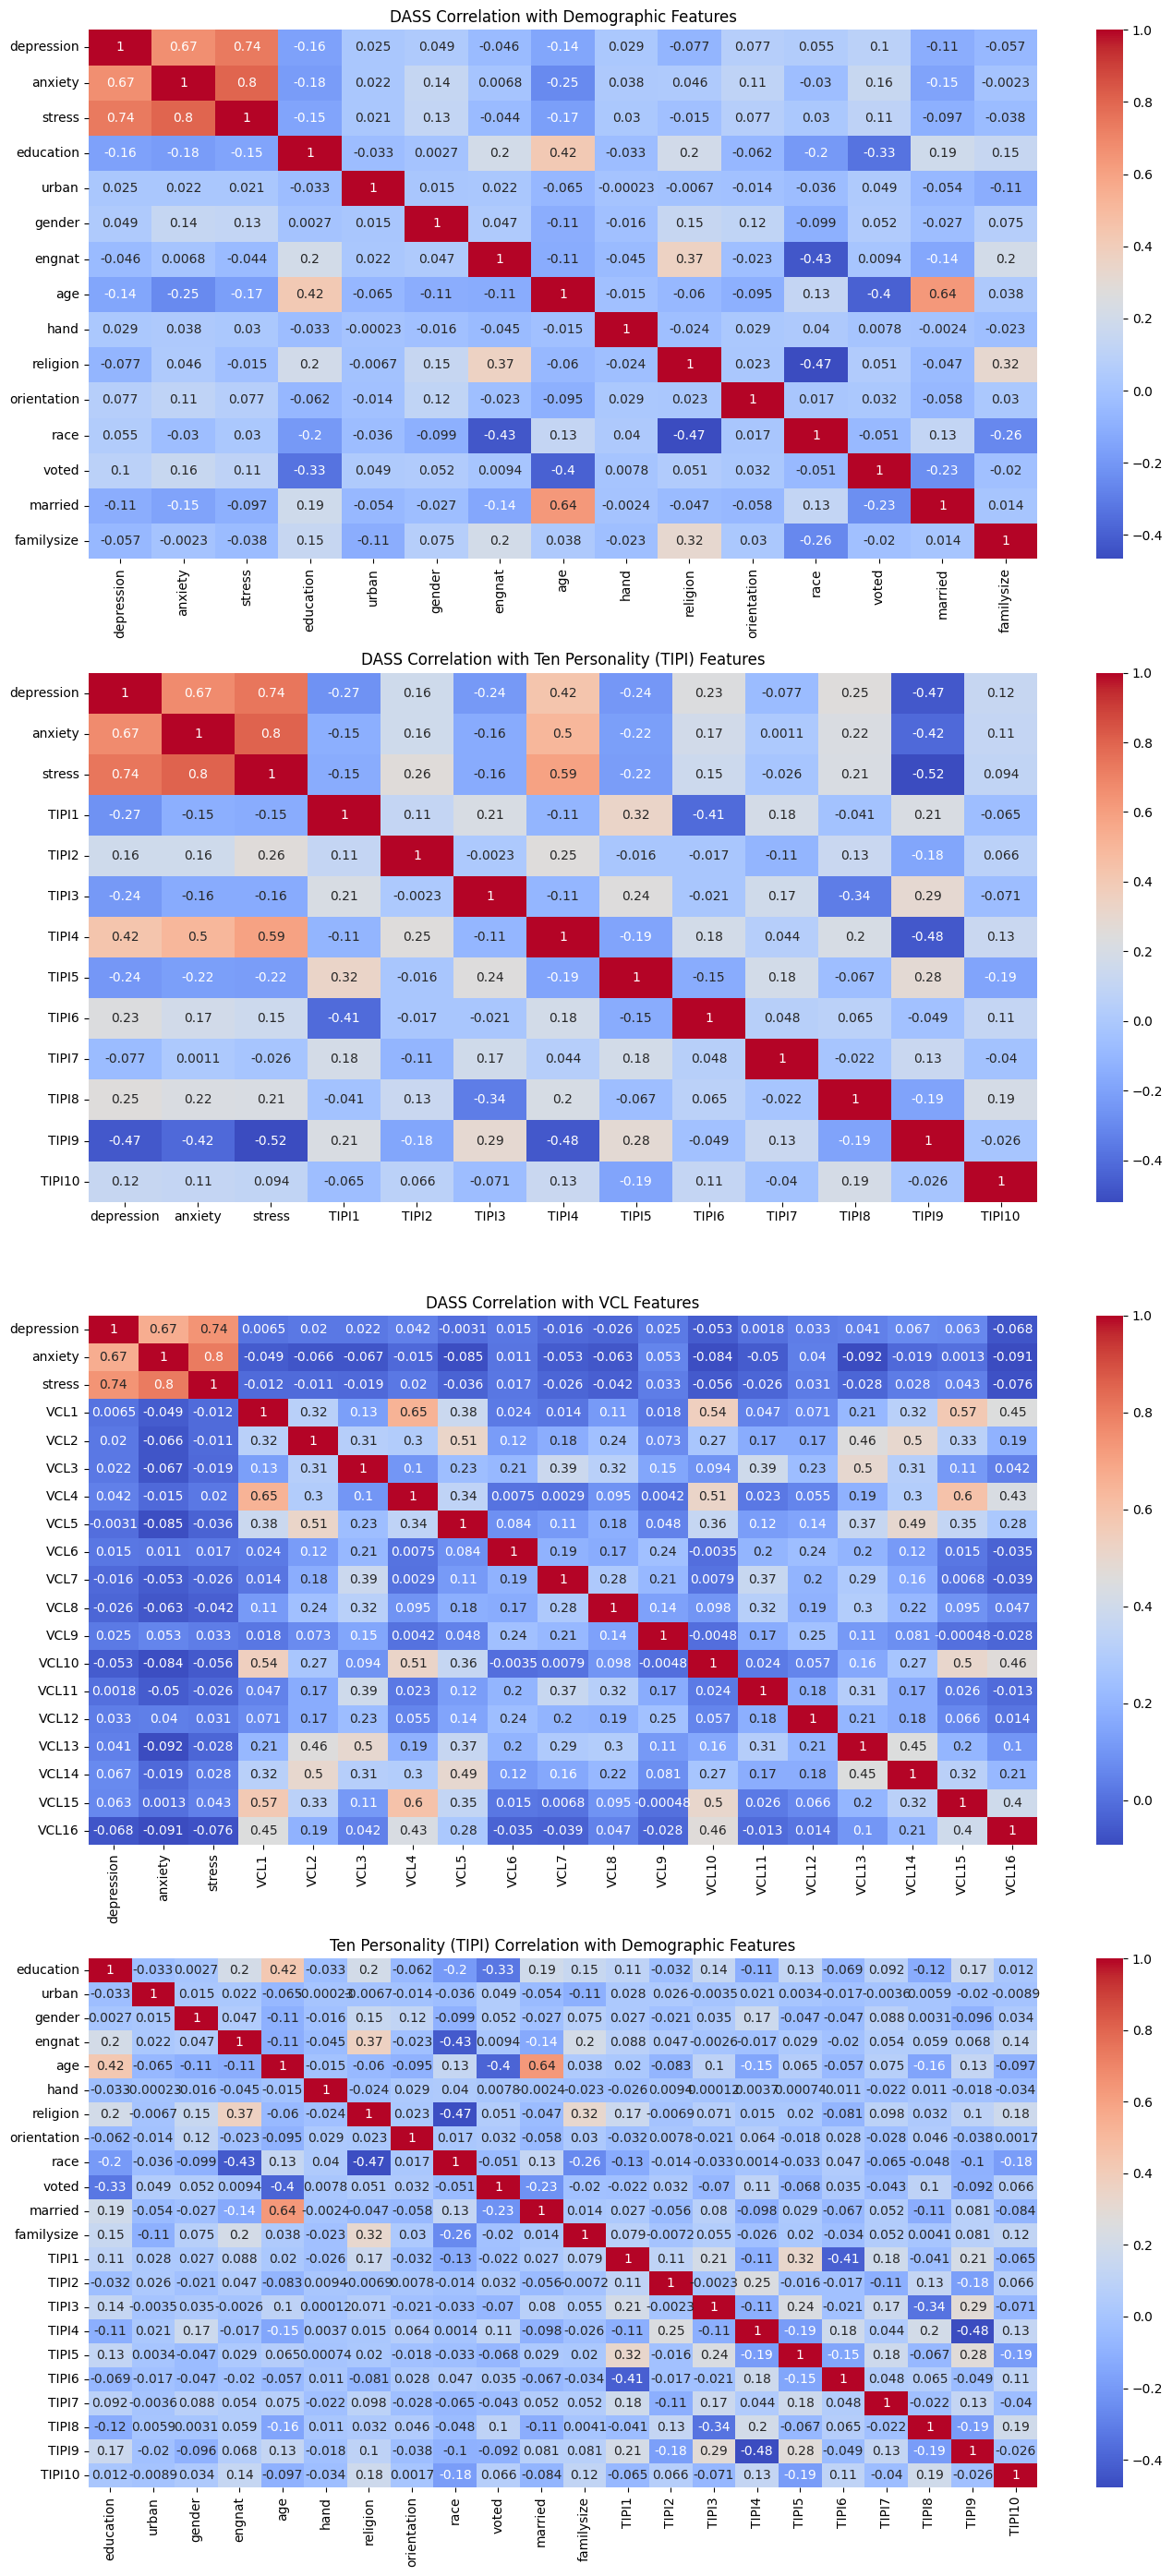

In [17]:
fig, axes = plt.subplots(4, figsize=(14, 28))

sns.heatmap(corr_matrix_demo, annot=True, cmap='coolwarm', ax=axes[0])
axes[0].set_title('DASS Correlation with Demographic Features')

sns.heatmap(corr_matrix_tipi, annot=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('DASS Correlation with Ten Personality (TIPI) Features')

sns.heatmap(corr_matrix_vcl, annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title('DASS Correlation with VCL Features')

sns.heatmap(corr_matrix_demo_tipi, annot=True, cmap='coolwarm', ax=axes[3])
axes[3].set_title('Ten Personality (TIPI) Correlation with Demographic Features')

plt.tight_layout()
plt.show()

### Visualization

#### Mapping

In [18]:
# New df. Used for mapping without replacing the values of the original dataset
df_mapped = df.copy()

In [19]:
# Demographic mapping
education_map = {1: 'Less than high school', 2: 'High school', 3: 'University degree', 4: 'Graduate degree'}
urban_map = {1: 'Rural (country side)', 2: 'Suburban', 3: 'Urban (town, city)'}
gender_map = {1: 'Male', 2: 'Female', 3: 'Other'}
engnat_map = {1: 'Yes', 2: 'No'}
hand_map = {1: 'Right', 2: 'Left', 3: 'Both'}
religion_map = {1: 'Agnostic', 2: 'Atheist', 3: 'Buddhist', 4: 'Christian (Catholic)', 5: 'Christian (Mormon)', 6: 'Christian (Protestant)', 7: 'Christian (Other)', 8: 'Hindu', 9: 'Jewish', 10: 'Muslim', 11: 'Sikh', 12: 'Other'}
orientation_map = {1: 'Heterosexual', 2: 'Bisexual', 3: 'Homosexual', 4: 'Asexual', 5: 'Other'}
race_map = {1: 'Asian', 2: 'Arab', 3: 'Black', 4: 'Indigenous Australian', 5: 'Native American', 6: 'White', 7: 'Other'}
voted_map = {1: 'Yes', 2: 'No'}
married_map = {1: 'Never married', 2: 'Currently married', 3: 'Previously married'}

df_mapped['education'] = df_mapped['education'].replace(education_map)
df_mapped['urban'] = df_mapped['urban'].replace(urban_map)
df_mapped['gender'] = df_mapped['gender'].replace(gender_map)
df_mapped['engnat'] = df_mapped['engnat'].replace(engnat_map)
df_mapped['hand'] = df_mapped['hand'].replace(hand_map)
df_mapped['religion'] = df_mapped['religion'].replace(religion_map)
df_mapped['orientation'] = df_mapped['orientation'].replace(orientation_map)
df_mapped['race'] = df_mapped['race'].replace(race_map)
df_mapped['voted'] = df_mapped['voted'].replace(voted_map)
df_mapped['married'] = df_mapped['married'].replace(married_map)

#### Demographic Features

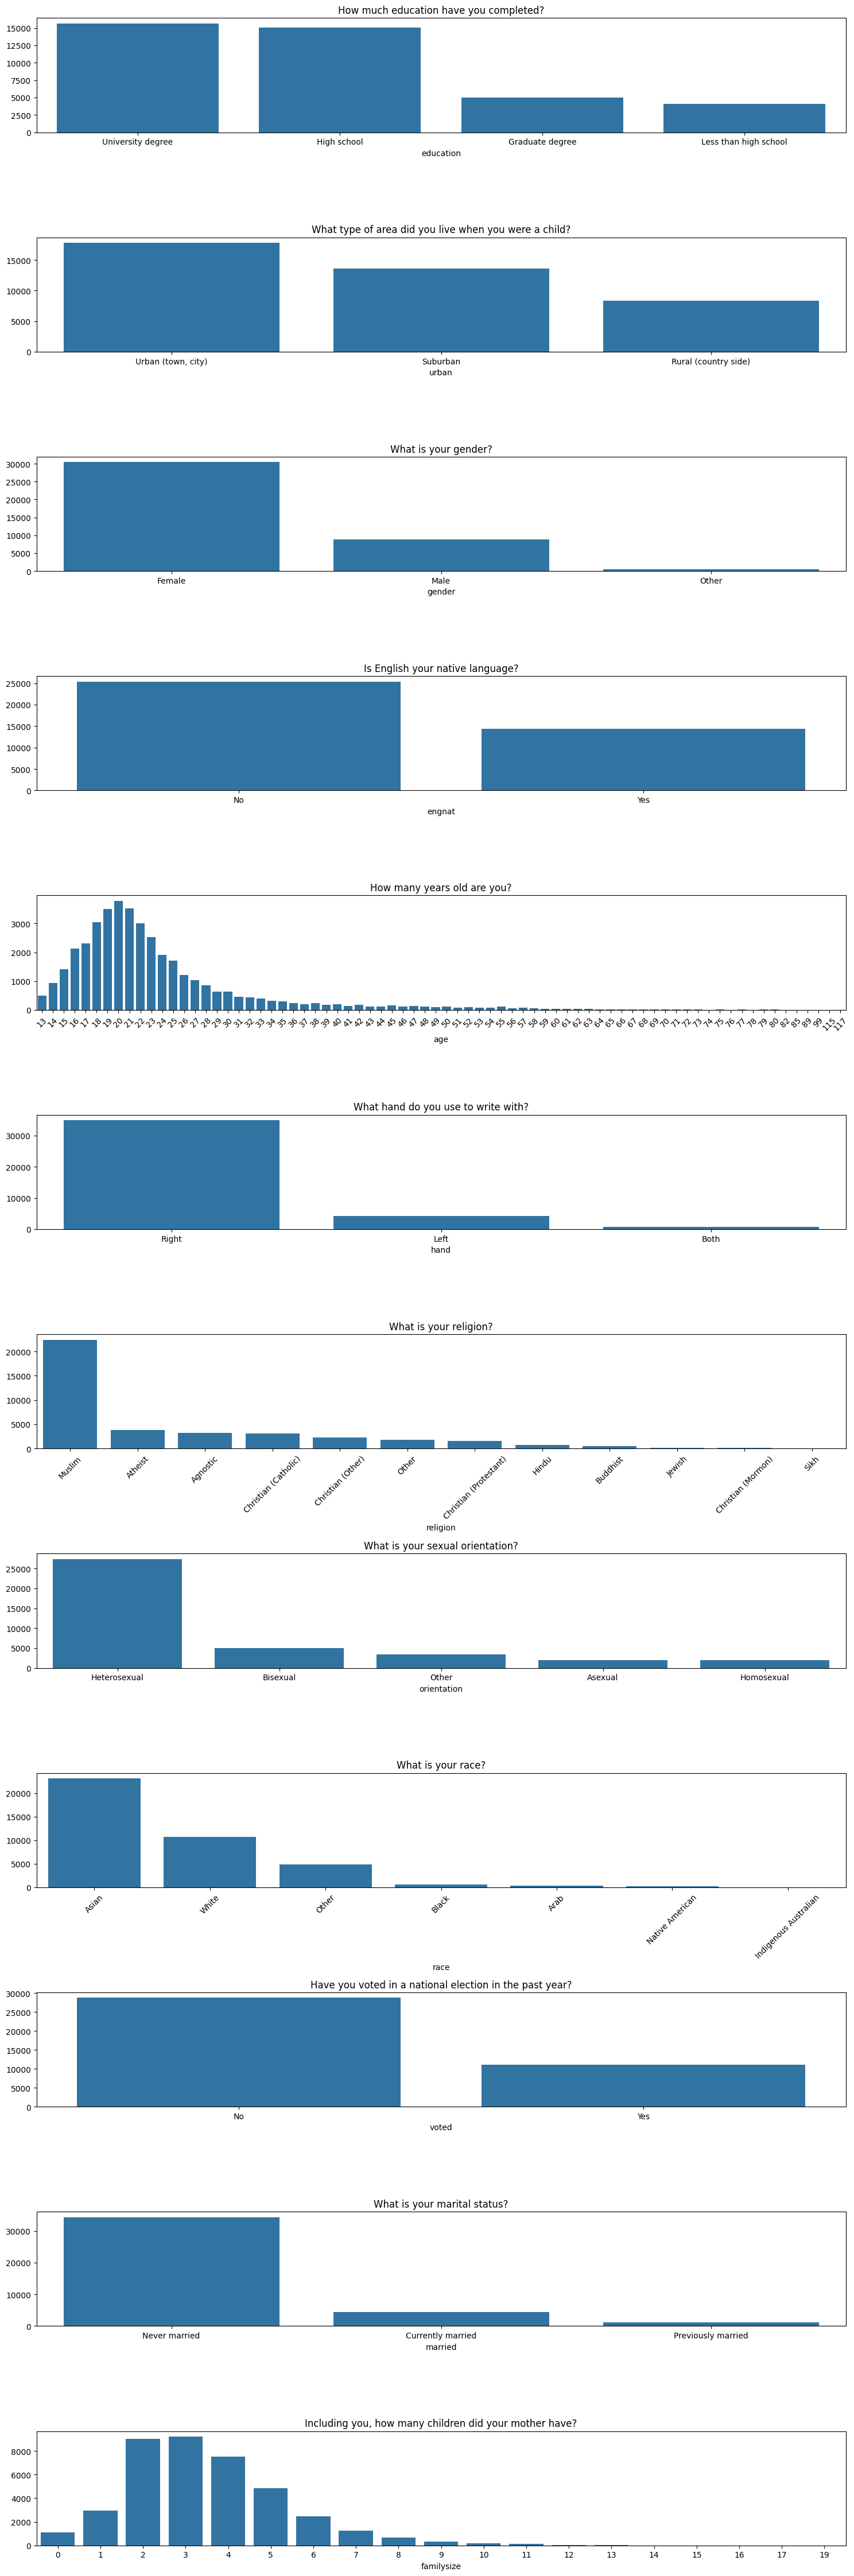

In [ ]:
# Demographic Features Visualization

# Subplots
fig, ax = plt.subplots(12, 1, figsize = (15,45)) # 12 Subplots for every demographic feature
fig.subplots_adjust(hspace=0.5) # Adjust spacing to avoid overlap

headers_visualized = ['education', 'urban', 'gender', 'engnat',
           'age', 'hand', 'religion', 'orientation',
           'race', 'voted', 'married', 'familysize']

for i, headers in enumerate(headers_visualized):
    header_counts = df_mapped[headers].value_counts()
    sns.barplot(x=header_counts.index, y=header_counts.values, ax=ax[i])
    ax[i].set_title(f'{demo_dict[headers]}')

    if headers == 'age' or headers == 'religion' or headers == 'race':
        ax[i].tick_params(axis='x', rotation=45)

fig.tight_layout() # Tighten Layout
plt.show()

#### TIPI Features

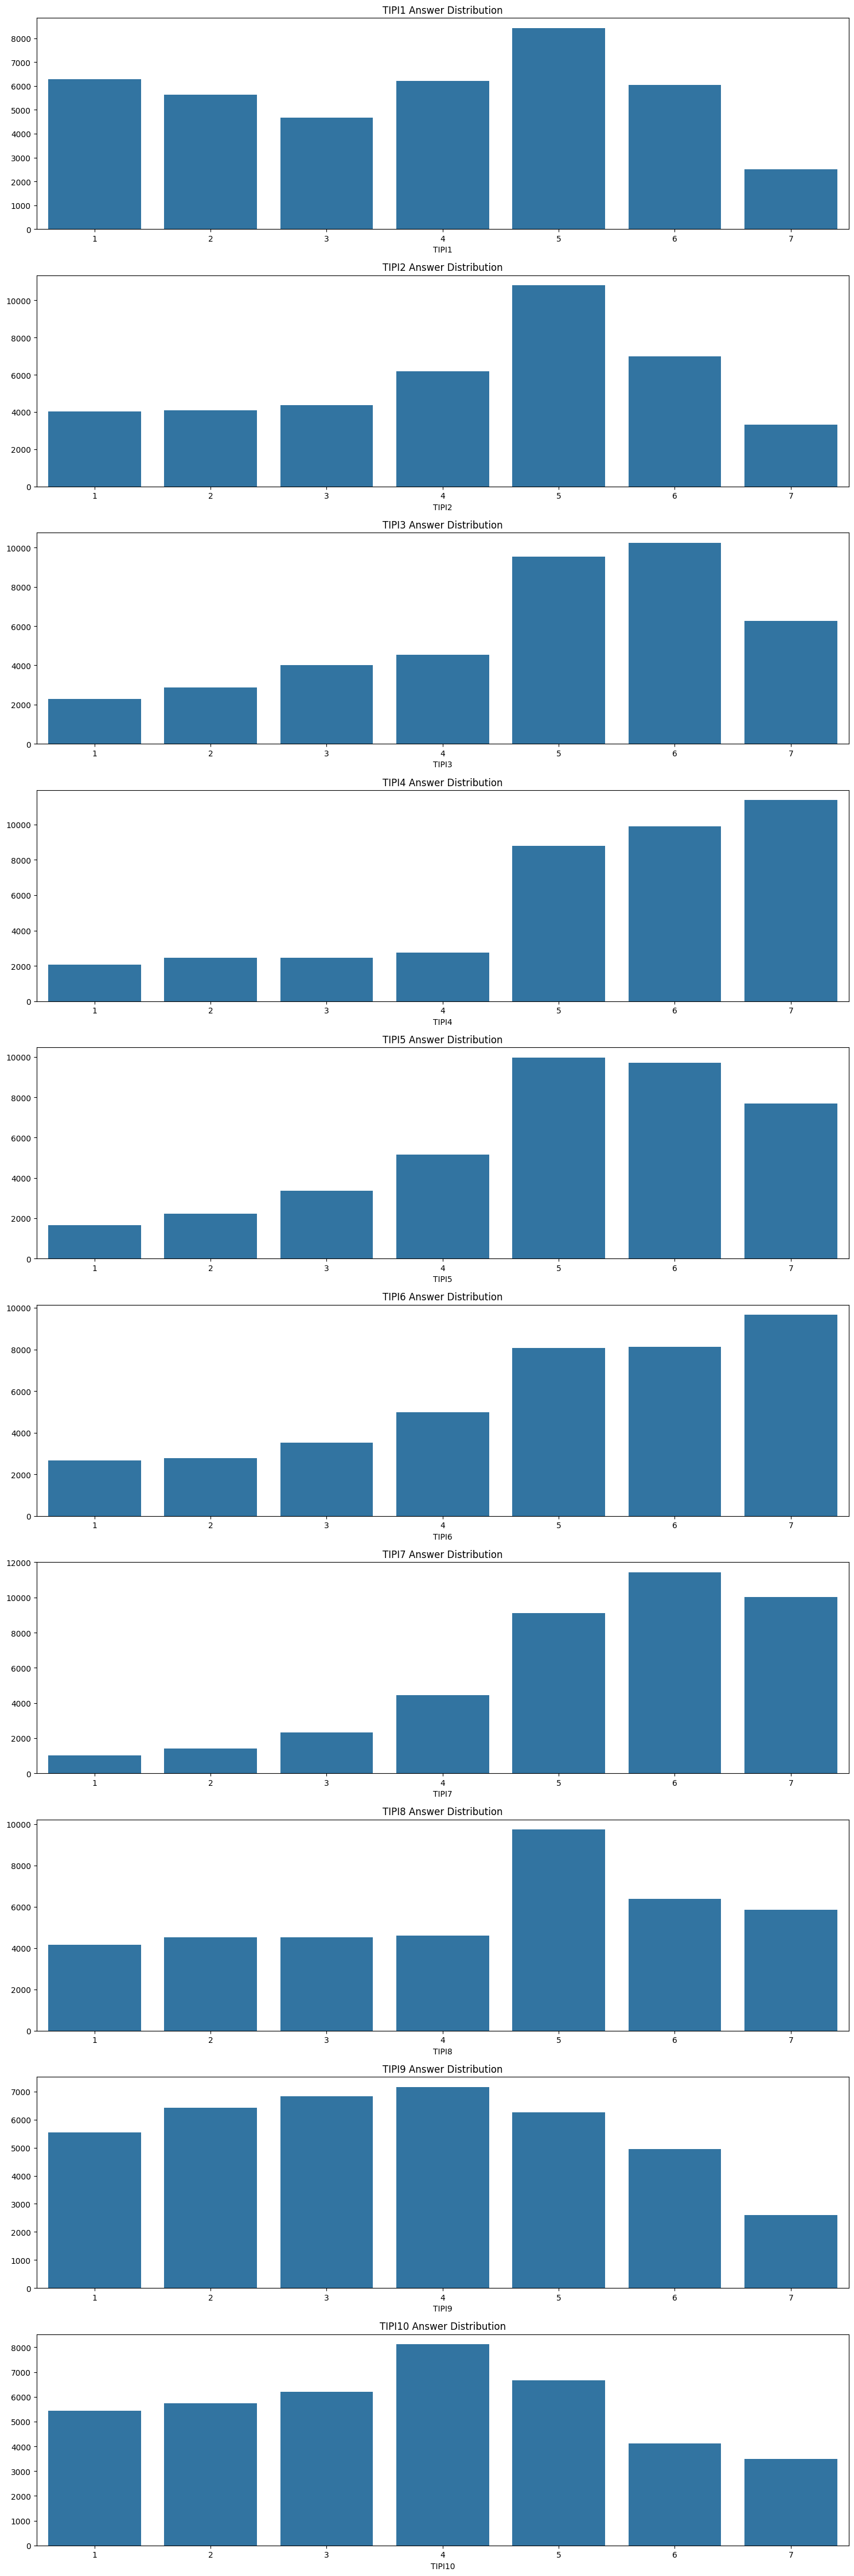

In [21]:
# Visualize TIPI For loop

# Subplots
fig, ax = plt.subplots(10, 1, figsize = (15,45))
fig.subplots_adjust(hspace=0.5)

# Declare TIPI Columns
tipi_columns = [f'TIPI{i}' for i in range(1, 11)]  # TIPI1 to TIPI10

# Visualize using for loop
for i, values in enumerate(tipi_columns):
    tipi_counts = df[values].value_counts()
    sns.barplot(x=tipi_counts.index, y=tipi_counts.values, ax=ax[i])  # Update for seaborn
    ax[i].set_title(f'TIPI{i + 1} Answer Distribution')  # TIPI is 1-based

fig.tight_layout()
plt.show()

### Descriptive Statistics

#### Depression Correlated Headers

In [22]:
# Married, voted, age, education
df[['married', 'voted', 'age', 'education']].describe()

,married,voted,age,education
count,39775.000000,39775.000000,39775.000000,39775.000000
mean,1.164450,1.722238,23.408825,2.542678
std,0.438543,0.447901,8.607236,0.839323
min,1.000000,1.000000,13.000000,1.000000
25%,1.000000,1.000000,18.000000,2.000000
50%,1.000000,2.000000,21.000000,3.000000
75%,1.000000,2.000000,25.000000,3.000000
max,3.000000,2.000000,117.000000,4.000000


In [23]:
# Skew
df[['married', 'voted', 'age', 'education']].skew()

married      2.725474
voted       -0.992401
age          2.347183
education   -0.014463
dtype: float64

In [24]:
# Kurtosis
df[['married', 'voted', 'age', 'education']].kurtosis()

married      6.888227
voted       -1.015192
age          7.355949
education   -0.587951
dtype: float64

#### Anxiety Correlated Headers

In [25]:
# Married, voted, orientation, age, gender, education
df[['married', 'voted', 'orientation', 'age', 'gender', 'education']].describe()

,married,voted,orientation,age,gender,education
count,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000
mean,1.164450,1.722238,1.721157,23.408825,1.792910,2.542678
std,0.438543,0.447901,1.281165,8.607236,0.438138,0.839323
min,1.000000,1.000000,1.000000,13.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,18.000000,2.000000,2.000000
50%,1.000000,2.000000,1.000000,21.000000,2.000000,3.000000
75%,1.000000,2.000000,2.000000,25.000000,2.000000,3.000000
max,3.000000,2.000000,5.000000,117.000000,3.000000,4.000000


In [26]:
# Skew
df[['married', 'voted', 'orientation', 'age', 'gender', 'education']].skew()

married        2.725474
voted         -0.992401
orientation    1.665312
age            2.347183
gender        -0.938754
education     -0.014463
dtype: float64

In [27]:
# Kurtosis
df[['married', 'voted', 'orientation', 'age', 'gender', 'education']].kurtosis()

married        6.888227
voted         -1.015192
orientation    1.347908
age            7.355949
gender         0.208264
education     -0.587951
dtype: float64

#### Stress Correlated Headers

In [28]:
# Married, voted, age, gender, education
df[['married', 'voted', 'age', 'gender', 'education']].describe()

,married,voted,age,gender,education
count,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000
mean,1.164450,1.722238,23.408825,1.792910,2.542678
std,0.438543,0.447901,8.607236,0.438138,0.839323
min,1.000000,1.000000,13.000000,1.000000,1.000000
25%,1.000000,1.000000,18.000000,2.000000,2.000000
50%,1.000000,2.000000,21.000000,2.000000,3.000000
75%,1.000000,2.000000,25.000000,2.000000,3.000000
max,3.000000,2.000000,117.000000,3.000000,4.000000


In [29]:
# Skew
df[['married', 'voted', 'age', 'gender', 'education']].skew()

married      2.725474
voted       -0.992401
age          2.347183
gender      -0.938754
education   -0.014463
dtype: float64

In [30]:
# Kurtosis
df[['married', 'voted', 'age', 'gender', 'education']].kurtosis()

married      6.888227
voted       -1.015192
age          7.355949
gender       0.208264
education   -0.587951
dtype: float64

### Finding Bias in the Dataset with Response Variable Analysis

In [31]:
# Response Variable Analysis (Meet 11 & 12)
# TODO: NOT PRIORITIZED. THERE'S NO CURRENT USE OTHER THAN KNOWING IF THERE ARE BIASES WITHIN THE MODEL. REVISIT LATER AFTER MODELS ARE BEING MADE
# Response Variable Analysis is used to find out which if there are biases within the dataset. 
# 1. Decide which independent variables (demographic or TIPI headers) to use with the dependent/response variable (depression, anxiety, stress features).
# 2. Use the correlation matrix to analyze whether the response variable has bias towards.
# 3. Implement methods to impute to make data unbiased - IMPOSSIBLE WITH CURRENT SKILL. USE BOOTSTRAP.

In [32]:
# Response Variable Analysis
# TODO: Use for loop to analyze the response variable with demographic headers.
# TODO: Use Age Grouping from feature engineered dataset.
# TODO: Currently only using demographic headers correlated with DASS. Explore other headers.

# Depression Grouped by Demographic Headers
depression_grouped_by_married = df.groupby('married')['depression'].describe()
depression_grouped_by_voted = df.groupby('voted')['depression'].describe()
depression_grouped_by_age = df.groupby('age')['depression'].describe()
depression_grouped_by_education = df.groupby('education')['depression'].describe()

# Anxiety Grouped by Demographic Headers
anxiety_grouped_by_married = df.groupby('married')['anxiety'].describe()
anxiety_grouped_by_voted = df.groupby('voted')['anxiety'].describe()
anxiety_grouped_by_age = df.groupby('age')['anxiety'].describe()
anxiety_grouped_by_education = df.groupby('education')['anxiety'].describe()
anxiety_grouped_by_orientation = df.groupby('orientation')['anxiety'].describe()
anxiety_grouped_by_gender = df.groupby('gender')['anxiety'].describe()

# Stress Grouped by Demographic Headers
stress_grouped_by_married = df.groupby('married')['stress'].describe()
stress_grouped_by_voted = df.groupby('voted')['stress'].describe()
stress_grouped_by_age = df.groupby('age')['stress'].describe()
stress_grouped_by_education = df.groupby('education')['stress'].describe()
stress_grouped_by_gender = df.groupby('gender')['stress'].describe()

In [33]:
print(depression_grouped_by_married)
print(depression_grouped_by_voted)
print(depression_grouped_by_age)
print(depression_grouped_by_education)

print(anxiety_grouped_by_married)
print(anxiety_grouped_by_voted)
print(anxiety_grouped_by_age)
print(anxiety_grouped_by_education)
print(anxiety_grouped_by_orientation)
print(anxiety_grouped_by_gender)

print(stress_grouped_by_married)
print(stress_grouped_by_voted)
print(stress_grouped_by_age)
print(stress_grouped_by_education)
print(stress_grouped_by_gender)

           count       mean        std  min   25%   50%   75%   max
married                                                            
1.0      34326.0  21.714793  12.210618  0.0  12.0  22.0  32.0  42.0
2.0       4357.0  16.166399  11.993038  0.0   6.0  14.0  25.0  42.0
3.0       1092.0  20.005495  12.624884  0.0   9.0  19.0  30.0  42.0
         count       mean        std  min   25%   50%   75%   max
voted                                                            
1.0    11048.0  19.079743  12.345120  0.0   9.0  18.0  29.0  42.0
2.0    28727.0  21.821701  12.227611  0.0  12.0  22.0  32.0  42.0
      count       mean        std   min    25%   50%    75%   max
age                                                              
13    489.0  26.922290  12.029425   0.0  17.00  29.0  38.00  42.0
14    933.0  26.691318  11.970327   0.0  18.00  28.0  38.00  42.0
15   1415.0  25.195053  12.140798   0.0  16.00  27.0  36.00  42.0
16   2123.0  24.318888  12.043025   0.0  15.00  25.0  35.00  42.0


#### Depression

In [34]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [35]:
group1 = df[df['married'] == 1]['depression']   # Never married
group2 = df[df['married'] == 2]['depression']   # Currently married
group3 = df[df['married'] == 3]['depression']   # Previously married

# Perform ANOVA 
f_stat, p_value = f_oneway(group1, group2, group3)

# Combine data into a single array and create a group label array
# Used in Tukey's HSD
all_data = pd.concat([group1, group2, group3], axis=0)
groups = (['Never Married'] * len(group1) + 
          ['Currently Married'] * len(group2) + 
          ['Previously Married'] * len(group3))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

# Perform Tukey's HSD
tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 404.12124816011544
p_value: 1.7860676073824115e-174

           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2       meandiff p-adj  lower   upper  reject
--------------------------------------------------------------------------
Currently Married      Never Married   5.5484   0.0  5.0886  6.0082   True
Currently Married Previously Married   3.8391   0.0  2.8715  4.8067   True
    Never Married Previously Married  -1.7093   0.0 -2.5882 -0.8304   True
--------------------------------------------------------------------------


Conclusion: <br>
P-value < 0.05. This means <b>marriage status </b> significantly affects depression scores.

In [36]:
group1 = df[df['voted'] == 1]['depression']   # Yes
group2 = df[df['voted'] == 2]['depression']   # No

f_stat, p_value = f_oneway(group1, group2)

all_data = pd.concat([group1, group2], axis=0)
groups = (['Voted Yes'] * len(group1) + 
          ['Voted No'] * len(group2))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 399.0972255936696
p_value: 2.3525570066849248e-88

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1    group2  meandiff p-adj lower   upper  reject
-------------------------------------------------------
Voted No Voted Yes   -2.742   0.0 -3.011 -2.4729   True
-------------------------------------------------------


Conclusion: <br>
P-value <= 0.05. This means voted significantly affects depression scores.

In [37]:
group1 = df[df['education'] == 1]['depression']   # Less than high school
group2 = df[df['education'] == 2]['depression']   # High school
group3 = df[df['education'] == 3]['depression']   # University degree
group4 = df[df['education'] == 4]['depression']   # Graduate degree

f_stat, p_value = f_oneway(group1, group2, group3, group4)

all_data = pd.concat([group1, group2, group3, group4], axis=0)
groups = (['Less than High School'] * len(group1) + 
          ['High School'] * len(group2) + 
          ['University Degree'] * len(group3) +
          ['Graduate Degree'] * len(group4))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

# TODO: Do Age with age_group from feature engineered dataset.

ANOVA (f_oneway) Results:
f_stat: 356.1798257499752
p_value: 2.772548507559563e-228

               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------------
      Graduate Degree           High School   4.4304   0.0  3.9208    4.94   True
      Graduate Degree Less than High School   6.7885   0.0   6.129   7.448   True
      Graduate Degree     University Degree   1.7634   0.0  1.2562  2.2707   True
          High School Less than High School   2.3581   0.0   1.806  2.9102   True
          High School     University Degree   -2.667   0.0 -3.0236 -2.3103   True
Less than High School     University Degree  -5.0251   0.0  -5.575 -4.4751   True
---------------------------------------------------------------------------------


#### Anxiety

In [38]:
group1 = df[df['married'] == 1]['anxiety']  # Never married
group2 = df[df['married'] == 2]['anxiety']  # Currently married
group3 = df[df['married'] == 3]['anxiety']  # Previously married

f_stat, p_value = f_oneway(group1, group2, group3)

all_data = pd.concat([group1, group2, group3], axis=0)
groups = (['Never Married'] * len(group1) + 
          ['Currently Married'] * len(group2) + 
          ['Previously Married'] * len(group3))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 614.6247464258358
p_value: 1.2996295815273122e-263

           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2       meandiff p-adj  lower   upper  reject
--------------------------------------------------------------------------
Currently Married      Never Married    5.431   0.0  5.0505  5.8115   True
Currently Married Previously Married   1.5681   0.0  0.7674  2.3688   True
    Never Married Previously Married  -3.8629   0.0 -4.5901 -3.1356   True
--------------------------------------------------------------------------


In [39]:
group1 = df[df['voted'] == 1]['anxiety']  # Yes
group2 = df[df['voted'] == 2]['anxiety']  # No

f_stat, p_value = f_oneway(group1, group2)

all_data = pd.concat([group1, group2], axis=0)
groups = (['Voted Yes'] * len(group1) + 
          ['Voted No'] * len(group2))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 987.1652573180402
p_value: 4.638845280643335e-214

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1    group2  meandiff p-adj  lower   upper  reject
--------------------------------------------------------
Voted No Voted Yes  -3.5611   0.0 -3.7832 -3.3389   True
--------------------------------------------------------


In [40]:
group1 = df[df['education'] == 1]['anxiety']  # Less than high school
group2 = df[df['education'] == 2]['anxiety']  # High school
group3 = df[df['education'] == 3]['anxiety']  # University degree
group4 = df[df['education'] == 4]['anxiety']  # Graduate degree

f_stat, p_value = f_oneway(group1, group2, group3, group4)

all_data = pd.concat([group1, group2, group3, group4], axis=0)
groups = (['Less than High School'] * len(group1) + 
          ['High School'] * len(group2) + 
          ['University Degree'] * len(group3) +
          ['Graduate Degree'] * len(group4))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 448.2333729232424
p_value: 1.9467104463052e-286

               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------------
      Graduate Degree           High School   4.2791   0.0  3.8567  4.7016   True
      Graduate Degree Less than High School   6.6382   0.0  6.0915  7.1849   True
      Graduate Degree     University Degree   2.0673   0.0  1.6468  2.4878   True
          High School Less than High School   2.3591   0.0  1.9014  2.8168   True
          High School     University Degree  -2.2118   0.0 -2.5075 -1.9162   True
Less than High School     University Degree  -4.5709   0.0 -5.0269  -4.115   True
---------------------------------------------------------------------------------


In [41]:
group1 = df[df['orientation'] == 1]['anxiety']  # Heterosexual
group2 = df[df['orientation'] == 2]['anxiety']  # Bisexual
group3 = df[df['orientation'] == 3]['anxiety']  # Homosexual
group4 = df[df['orientation'] == 4]['anxiety']  # Asexual
group5 = df[df['orientation'] == 5]['anxiety']  # Other

f_stat, p_value = f_oneway(group1, group2, group3, group4, group5)

all_data = pd.concat([group1, group2, group3, group4, group5], axis=0)
groups = (['Heterosexual'] * len(group1) + 
          ['Bisexual'] * len(group2) + 
          ['Homosexual'] * len(group3) +
            ['Asexual'] * len(group4) +
            ['Other'] * len(group5))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 215.02389267393963
p_value: 7.06002322855501e-183

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
     Asexual     Bisexual   1.1659 0.0001  0.4309  1.9008   True
     Asexual Heterosexual  -2.4882    0.0 -3.1325 -1.8438   True
     Asexual   Homosexual  -0.3632 0.7945 -1.2457  0.5192  False
     Asexual        Other   0.8536 0.0237  0.0736  1.6337   True
    Bisexual Heterosexual   -3.654    0.0 -4.0792 -3.2288   True
    Bisexual   Homosexual  -1.5291    0.0 -2.2669 -0.7913   True
    Bisexual        Other  -0.3122 0.6325 -0.9238  0.2994  False
Heterosexual   Homosexual   2.1249    0.0  1.4773  2.7725   True
Heterosexual        Other   3.3418    0.0  2.8427  3.8409   True
  Homosexual        Other   1.2169 0.0002  0.4342  1.9996   True
----------------------------------------------------------------


In [42]:
group1 = df[df['gender'] == 1]['anxiety']   # Male
group2 = df[df['gender'] == 2]['anxiety']   # Female
group3 = df[df['gender'] == 3]['anxiety']   # Other

f_stat, p_value = f_oneway(group1, group2, group3)

all_data = pd.concat([group1, group2, group3], axis=0)
groups = (['Male'] * len(group1) +
            ['Female'] * len(group2) +
            ['Other'] * len(group3))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 422.0935800539064
p_value: 4.03142216939349e-182

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Female   Male  -3.3287   0.0 -3.6165 -3.0408   True
Female  Other    3.806   0.0  2.7851  4.8269   True
  Male  Other   7.1347   0.0  6.0916  8.1777   True
---------------------------------------------------


#### Stress

In [43]:
group1 = df[df['married'] == 1]['stress']  # Never married
group2 = df[df['married'] == 2]['stress']  # Currently married
group3 = df[df['married'] == 3]['stress']  # Previously married

f_stat, p_value = f_oneway(group1, group2, group3)

all_data = pd.concat([group1, group2, group3], axis=0)
groups = (['Never Married'] * len(group1) + 
          ['Currently Married'] * len(group2) + 
          ['Previously Married'] * len(group3))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 240.85130158010463
p_value: 1.0665451614040643e-104

            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2       meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------------
Currently Married      Never Married   3.5284    0.0  3.1341  3.9227   True
Currently Married Previously Married   1.0557 0.0081   0.226  1.8854   True
    Never Married Previously Married  -2.4728    0.0 -3.2264 -1.7191   True
---------------------------------------------------------------------------


In [44]:
group1 = df[df['voted'] == 1]['stress']  # Yes
group2 = df[df['voted'] == 2]['stress']  # No

f_stat, p_value = f_oneway(group1, group2)

all_data = pd.concat([group1, group2], axis=0)
groups = (['Voted Yes'] * len(group1) + 
          ['Voted No'] * len(group2))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 501.8194422561174
p_value: 1.8472408653394417e-110

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1    group2  meandiff p-adj lower   upper  reject
-------------------------------------------------------
Voted No Voted Yes  -2.6226   0.0 -2.852 -2.3931   True
-------------------------------------------------------


In [45]:
group1 = df[df['education'] == 1]['stress']  # Less than high school
group2 = df[df['education'] == 2]['stress']  # High school
group3 = df[df['education'] == 3]['stress']  # University degree
group4 = df[df['education'] == 4]['stress']  # Graduate degree

f_stat, p_value = f_oneway(group1, group2, group3, group4)

all_data = pd.concat([group1, group2, group3, group4], axis=0)
groups = (['Less than High School'] * len(group1) + 
          ['High School'] * len(group2) + 
          ['University Degree'] * len(group3) +
          ['Graduate Degree'] * len(group4))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 314.7116407530967
p_value: 5.809869884178795e-202

               Multiple Comparison of Means - Tukey HSD, FWER=0.05               
        group1                group2        meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------------
      Graduate Degree           High School   3.4136   0.0  2.9778  3.8495   True
      Graduate Degree Less than High School   5.7056   0.0  5.1415  6.2697   True
      Graduate Degree     University Degree   1.4708   0.0  1.0369  1.9047   True
          High School Less than High School    2.292   0.0  1.8197  2.7642   True
          High School     University Degree  -1.9428   0.0 -2.2479 -1.6378   True
Less than High School     University Degree  -4.2348   0.0 -4.7052 -3.7644   True
---------------------------------------------------------------------------------


In [46]:
group1 = df[df['gender'] == 1]['stress'] # Male
group2 = df[df['gender'] == 2]['stress'] # Female
group3 = df[df['gender'] == 3]['stress'] # Other

f_stat, p_value = f_oneway(group1, group2, group3)

all_data = pd.concat([group1, group2, group3], axis=0)
groups = (['Male'] * len(group1) +
          ['Female'] * len(group2) +
            ['Other'] * len(group3))

# Print F-stat and p-value
print(f'ANOVA (f_oneway) Results:\nf_stat: {f_stat}\np_value: {p_value}')

tukey_results = pairwise_tukeyhsd(endog=all_data, groups=groups, alpha=0.05)
print(f'\n{tukey_results}')

ANOVA (f_oneway) Results:
f_stat: 359.2236697587744
p_value: 2.4181512038933736e-155

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Female   Male  -3.1738   0.0 -3.4698 -2.8778   True
Female  Other   3.4573   0.0  2.4074  4.5071   True
  Male  Other   6.6311   0.0  5.5585  7.7037   True
---------------------------------------------------


#### Biases Visualization

<Axes: xlabel='married', ylabel='depression'>

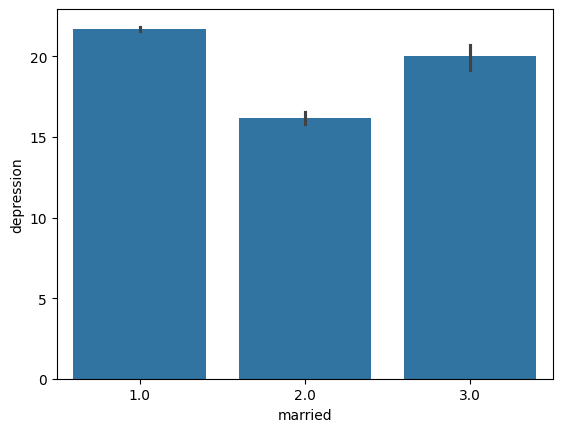

In [47]:
sns.barplot(data = df, x = 'married', y = 'depression')

In [48]:
# Declare correlated columns variable
depression_correlated_columns = ['married', 'voted', 'age', 'education']
anxiety_correlated_columns = ['married', 'voted', 'age', 'education', 'orientation']
stress_correlated_columns = ['married', 'voted', 'age', 'education', 'gender']

# TODO: Implement age_group from feature engineered dataset

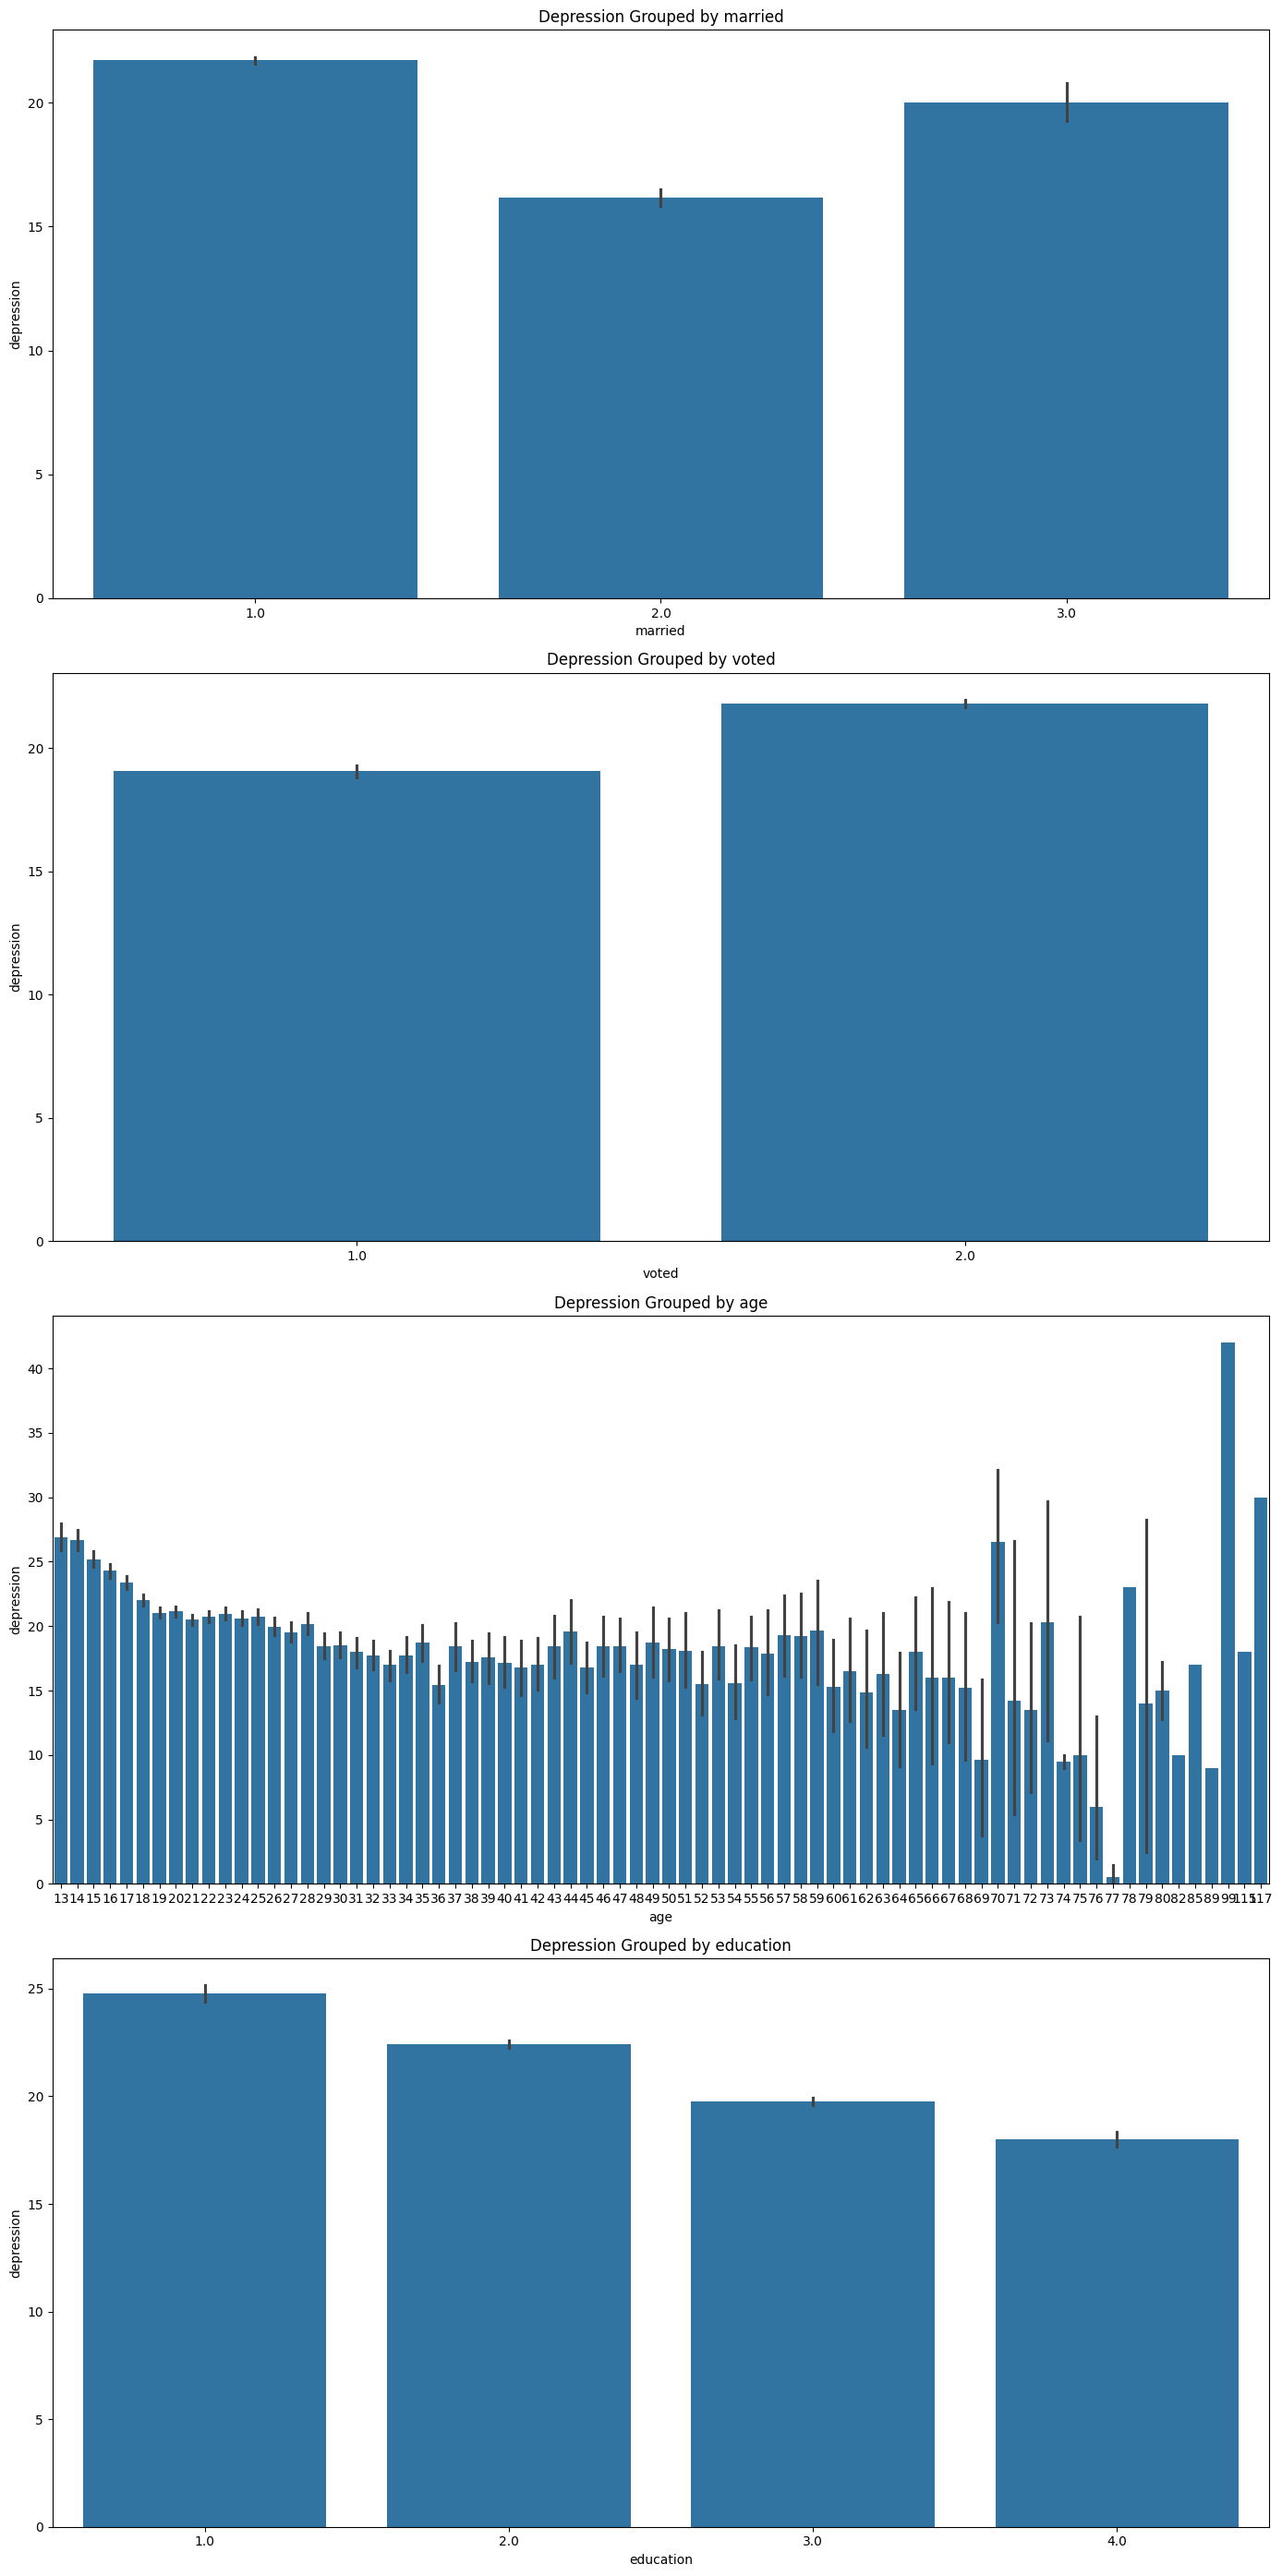

In [49]:
# Depression Visualization (For Loop)
fig, ax = plt.subplots(4, figsize=(14, 28))

fig.subplots_adjust(hspace=0.5)

for i, values in enumerate(depression_correlated_columns):
    sns.barplot(data = df, x = values, y = 'depression', ax=ax[i])
    ax[i].set_title(f'Depression Grouped by {values}')

fig.tight_layout()
plt.show()

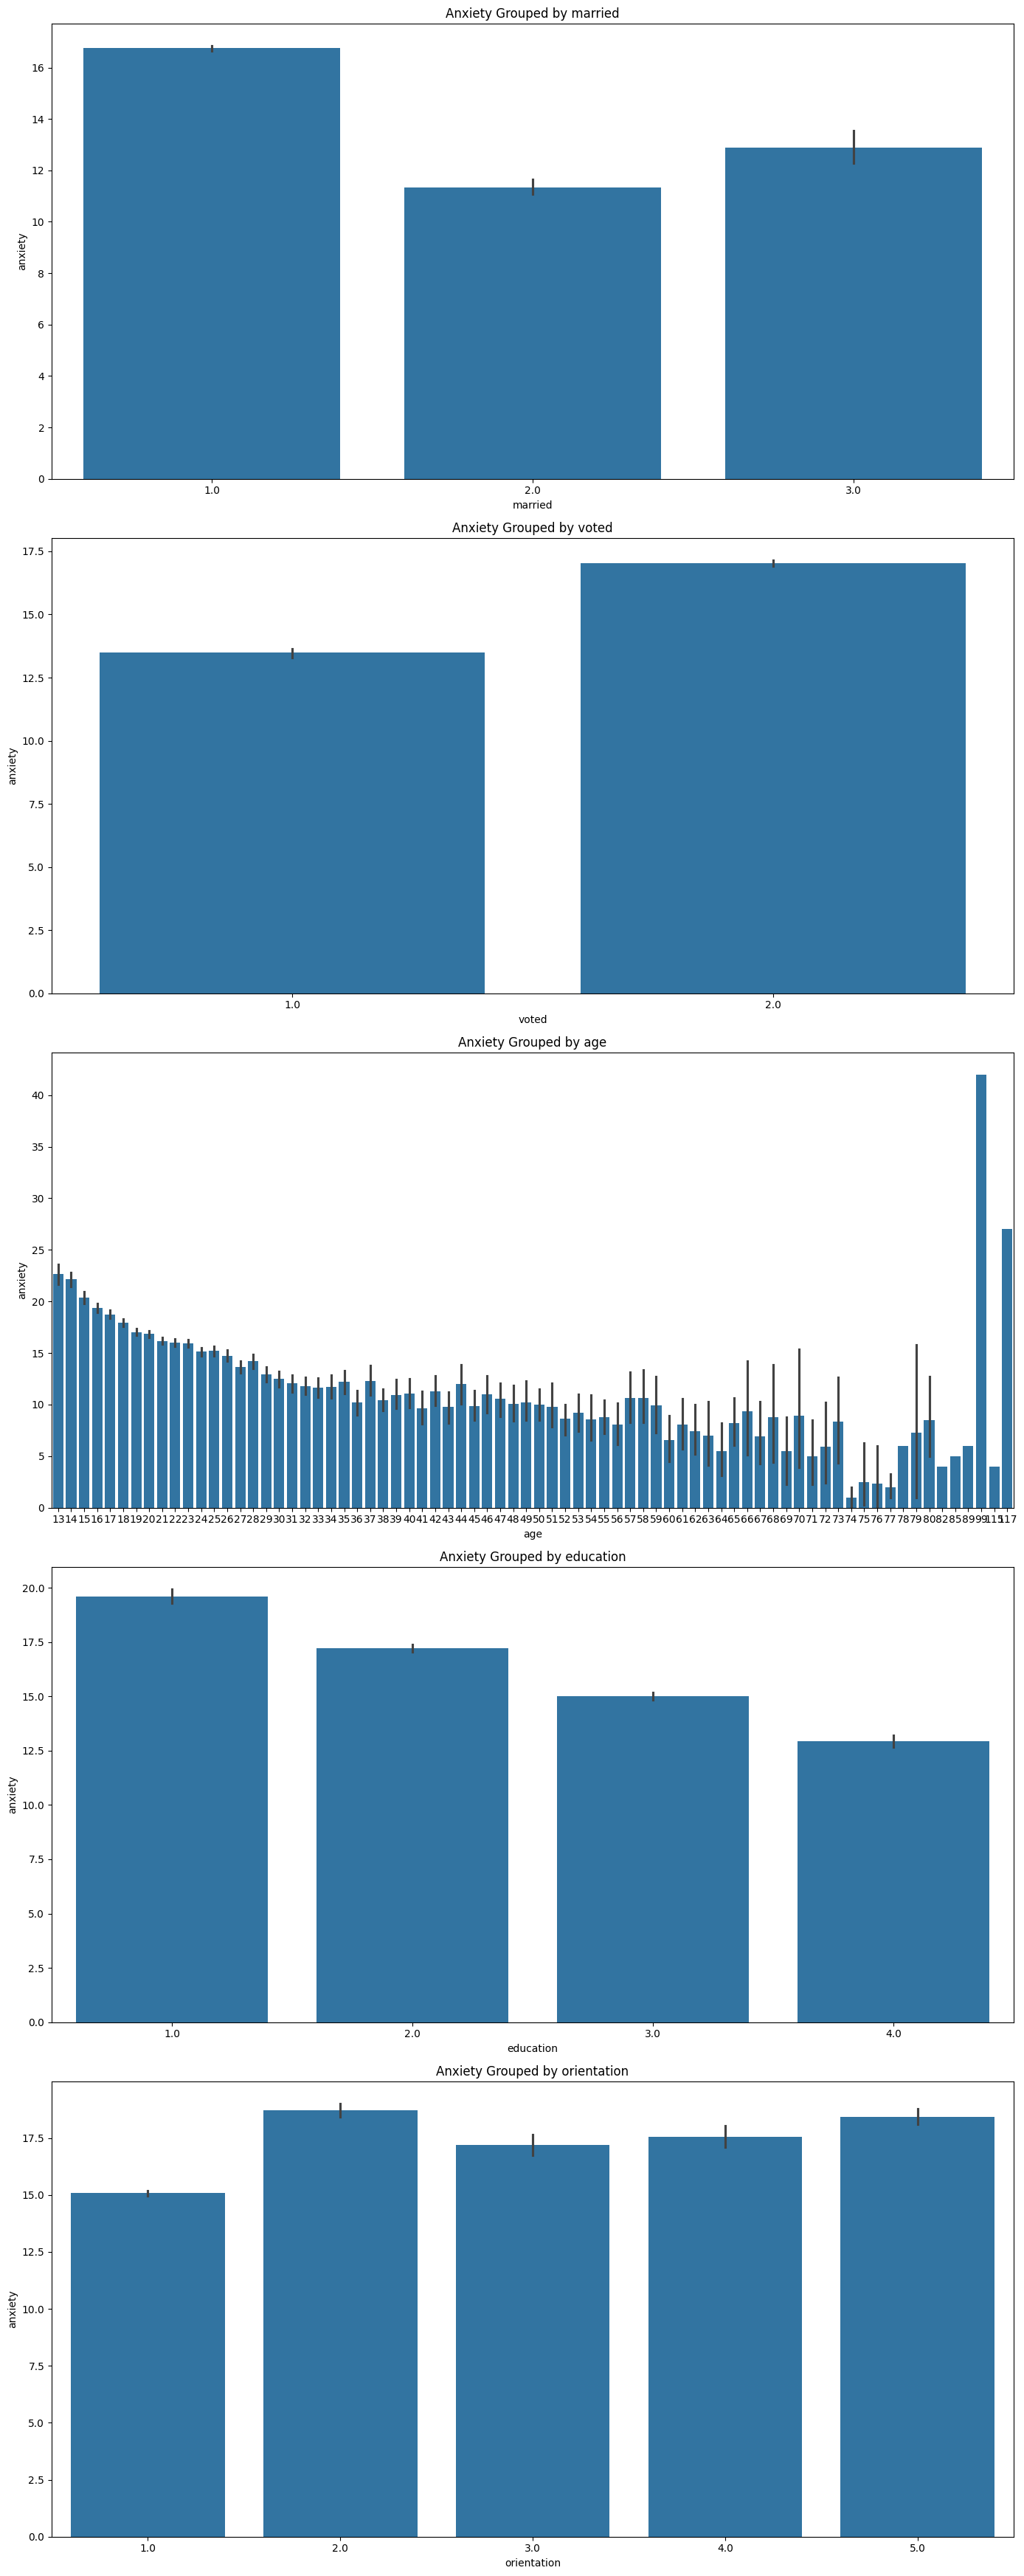

In [50]:
# Anxiety Visualization (For Loop)

fig, ax = plt.subplots(5, figsize=(14, 35))

fig.subplots_adjust(hspace=0.5)

for i, values in enumerate(anxiety_correlated_columns):
    sns.barplot(data = df, x = values, y = 'anxiety', ax=ax[i])
    ax[i].set_title(f'Anxiety Grouped by {values}')

fig.tight_layout()
plt.show()

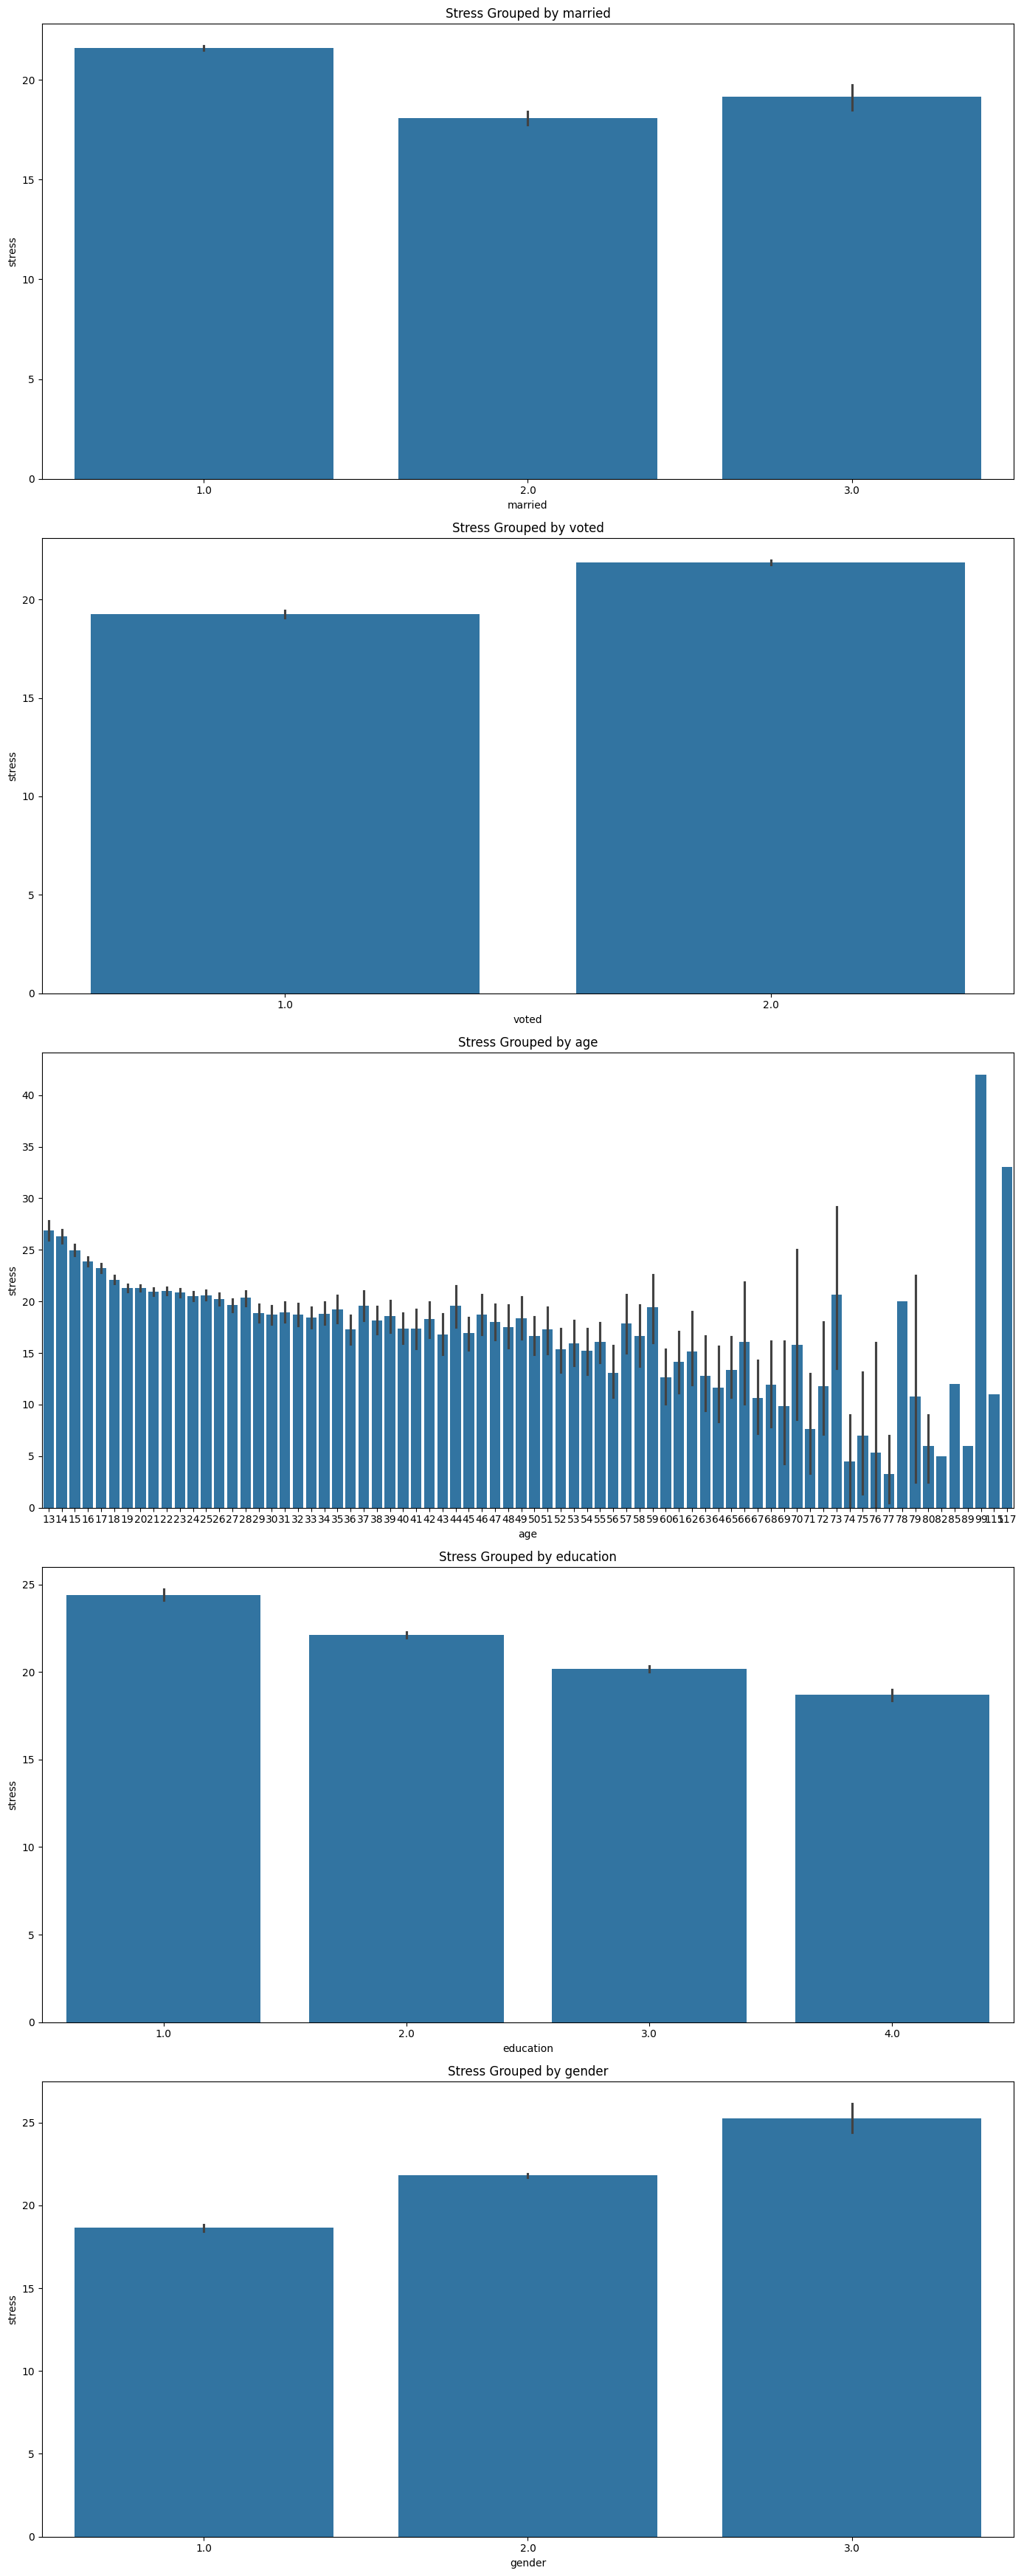

In [51]:
# Stress Visualization (For Loop)

fig, ax = plt.subplots(5, figsize=(14, 35))

fig.subplots_adjust(hspace=0.5)

for i, values in enumerate(stress_correlated_columns):
    sns.barplot(data = df, x = values, y = 'stress', ax=ax[i])
    ax[i].set_title(f'Stress Grouped by {values}')

fig.tight_layout()
plt.show()

In [52]:
def plot_scatter(data, x_column, y_column, title="Scatter Plot"):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=x_column, y=y_column, data=data, palette='coolwarm')
    plt.title(title)
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.show()

C:\Users\mfaiq\AppData\Local\Temp\ipykernel_28308\2925144381.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=x_column, y=y_column, data=data, palette='coolwarm')


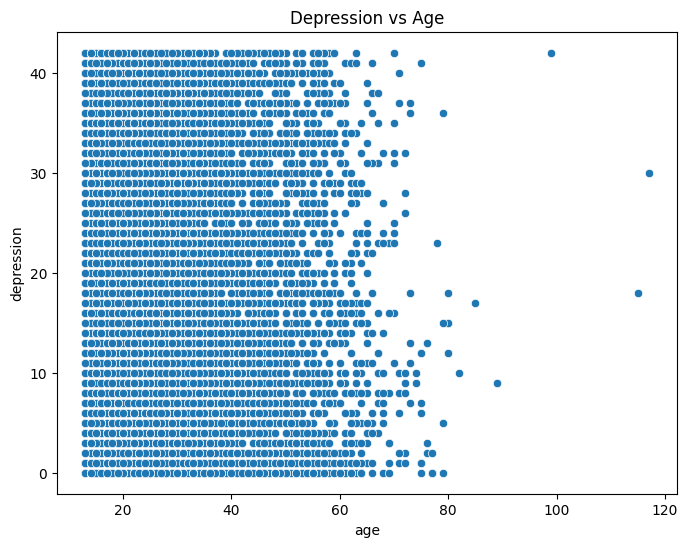

C:\Users\mfaiq\AppData\Local\Temp\ipykernel_28308\2925144381.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=x_column, y=y_column, data=data, palette='coolwarm')


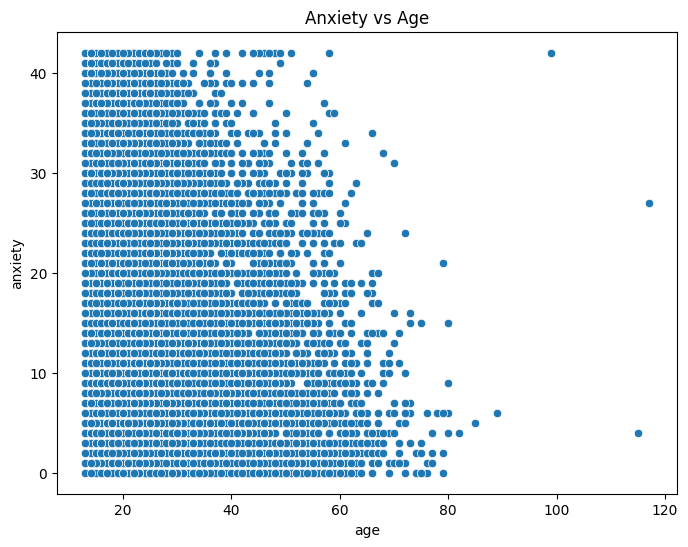

C:\Users\mfaiq\AppData\Local\Temp\ipykernel_28308\2925144381.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=x_column, y=y_column, data=data, palette='coolwarm')


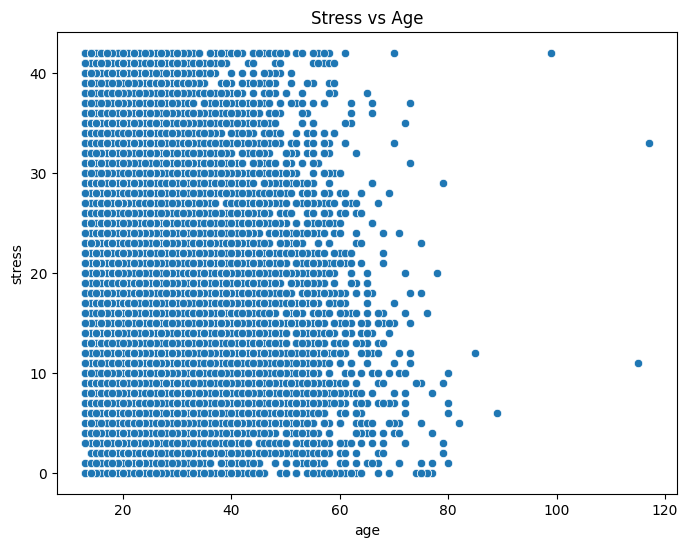

In [53]:
plot_scatter(df, 'age', 'depression', title="Depression vs Age")
plot_scatter(df, 'age', 'anxiety', title="Anxiety vs Age")
plot_scatter(df, 'age', 'stress', title="Stress vs Age")